# 05 · Data Quality & Validation

The v0.2 milestone hardens the lab against messy, drifting public data. This notebook tours the `carbon_transition_duckdb.quality` toolkit:

1. **Schema validation** — catch OWID column drift early.
2. **Ingestion metadata** — know where each row came from and when.
3. **Reproducible manifests** — checksums that pin a build's inputs.
4. **Missingness reports** — make data gaps visible.
5. **Country normalization** — stabilise inconsistent country labels.
6. **Country-group filters** — slice by World / EU / OECD / income.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


def find_repo_root(start: Path | None = None) -> Path:
    """Walk upwards until the directory containing pyproject.toml is found."""
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    return here


REPO_ROOT = find_repo_root()
RAW_DIR = REPO_ROOT / "data" / "raw"
DB_PATH = REPO_ROOT / "data" / "processed" / "carbon_transition.duckdb"
MARTS_DIR = REPO_ROOT / "data" / "processed" / "marts"
MANIFEST_PATH = REPO_ROOT / "data" / "processed" / "data_manifest.json"
print(f"Repository root: {REPO_ROOT}")


Repository root: C:\Users\diogo\work_code\portfolio\carbon-transition-duckdb-lab


In [2]:
from carbon_transition_duckdb.config import ProjectPaths
from carbon_transition_duckdb.pipeline import build_duckdb_lakehouse
from carbon_transition_duckdb.sample_data import generate_synthetic_owid_data

# Build the lakehouse on demand so the notebook is runnable in isolation.
if not DB_PATH.exists():
    generate_synthetic_owid_data(RAW_DIR, start_year=2010, end_year=2024)
result = build_duckdb_lakehouse(
    ProjectPaths(raw_dir=RAW_DIR, database=DB_PATH, export_dir=MARTS_DIR)
)
print("Ingested at:", result.ingested_at)
print("Manifest   :", result.manifest_path.name)


Ingested at: 2026-06-06 19:59:49
Manifest   : data_manifest.json


## 1. Schema validation

The build already fails fast on drift. Here we inspect the reports directly, then simulate a dropped column to show drift detection.

In [3]:
import duckdb

from carbon_transition_duckdb.quality.schema import (
    RAW_CO2_SCHEMA,
    validate_connection_schemas,
    validate_table_schema,
)

con = duckdb.connect(str(DB_PATH))
reports = validate_connection_schemas(con)
con.close()
for r in reports:
    print(f"{r.table:18} valid={r.is_valid}  missing={list(r.missing)}  "
          f"extra={len(r.extra)} extra cols")

raw_owid_co2       valid=True  missing=[]  extra=4 extra cols
raw_owid_energy    valid=True  missing=[]  extra=3 extra cols


In [4]:
# Simulate OWID dropping the `co2` column.
drifted = [c for c in RAW_CO2_SCHEMA.required_columns if c != 'co2']
report = validate_table_schema(drifted, RAW_CO2_SCHEMA)
print('is_valid:', report.is_valid)
print('missing :', list(report.missing))

is_valid: False
missing : ['co2']


## 2. Row-level ingestion metadata

Every raw row is stamped with its source file and the build timestamp.

In [5]:
con = duckdb.connect(str(DB_PATH))
meta = con.execute(
    'SELECT _source_file, _ingested_at, COUNT(*) AS rows '
    'FROM raw_owid_co2 GROUP BY 1, 2'
).fetchdf()
con.close()
meta

,_source_file,_ingested_at,rows
0,owid-co2-data.csv,2026-06-06 19:59:49,75


## 3. Reproducible manifest with checksums

The build writes a SHA-256 manifest of the raw inputs. Re-verifying it confirms the files behind the current database are unchanged.

In [6]:
import json

from carbon_transition_duckdb.quality.manifest import verify_manifest

print(json.dumps(json.loads(MANIFEST_PATH.read_text()), indent=2))
print('\nVerification:', verify_manifest(MANIFEST_PATH, RAW_DIR))

{
  "owid-co2-data.csv": {
    "name": "owid-co2-data.csv",
    "size_bytes": 4509,
    "n_rows": 75,
    "sha256": "6bda478a6b217ed10c081298bd72234515ec20925bdd63ff45f9a858c180b434"
  },
  "owid-energy-data.csv": {
    "name": "owid-energy-data.csv",
    "size_bytes": 4597,
    "n_rows": 75,
    "sha256": "fb5593eae7628ca26bdfcc9d425c126dccd49fc39bb6d05b65ae701f11e0001b"
  }
}

Verification: {'owid-co2-data.csv': True, 'owid-energy-data.csv': True}


## 4. Missingness reports

The synthetic data is complete, so to show the reports doing real work we punch a few holes into a copy of the mart and measure the gaps.

In [7]:
from carbon_transition_duckdb.pipeline import load_transition_mart
from carbon_transition_duckdb.quality.missingness import (
    missingness_by_country,
    missingness_by_metric,
)

mart = load_transition_mart(DB_PATH)
gapped = mart.copy()
# Drop renewable data for one country and a slice of carbon intensity.
gapped.loc[gapped['country'] == 'Deltora', 'renewables_share_elec'] = pd.NA
gapped.loc[gapped['year'] < 2013, 'carbon_intensity'] = pd.NA
missingness_by_metric(gapped)

,metric,n_total,n_missing,pct_missing
0,carbon_intensity,75,15,20.0
1,renewables_share_elec,75,15,20.0
2,co2_per_capita,75,0,0.0
3,co2,75,0,0.0
4,primary_energy_consumption,75,0,0.0
5,fossil_share_energy,75,0,0.0
6,renewables_share_energy,75,0,0.0
7,electricity_generation,75,0,0.0


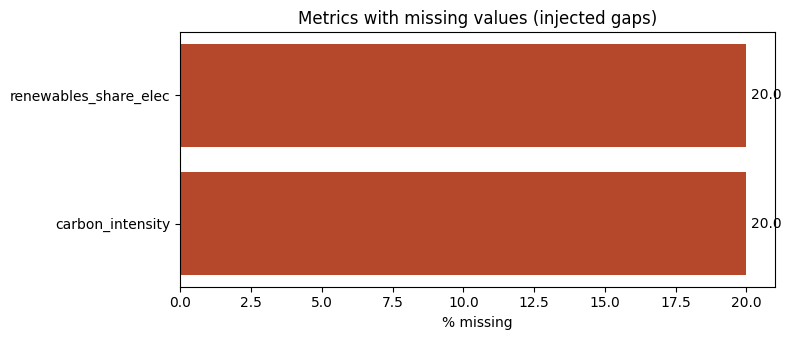

In [8]:
by_metric = missingness_by_metric(gapped)
nonzero = by_metric[by_metric['pct_missing'] > 0]
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(nonzero['metric'], nonzero['pct_missing'], color='#b5482a')
ax.set_xlabel('% missing')
ax.set_title('Metrics with missing values (injected gaps)')
ax.bar_label(ax.containers[0], fmt='%.1f', padding=3)
fig.tight_layout()
plt.show()

In [9]:
missingness_by_country(gapped).head()

,country,n_rows,n_cells,n_missing,pct_missing
0,Deltora,15,120,18,15.0
1,Atlantis,15,120,3,2.5
2,Borealia,15,120,3,2.5
3,Cyrenia,15,120,3,2.5
4,Estavia,15,120,3,2.5


## 5. Country normalization

Different sources spell the same country differently. Normalization maps common aliases onto a canonical name so joins and group lookups are stable.

In [10]:
from carbon_transition_duckdb.quality.normalization import (
    normalize_country_column,
    normalize_country_name,
)

examples = ['USA', 'Czech Republic', 'Russian Federation', 'Atlantis']
for name in examples:
    print(f"{name:22} -> {normalize_country_name(name)}")

normalize_country_column(pd.DataFrame({'country': examples}))

USA                    -> United States
Czech Republic         -> Czechia
Russian Federation     -> Russia
Atlantis               -> Atlantis


,country
0,United States
1,Czechia
2,Russia
3,Atlantis


## 6. Country-group filters & flags

Groups are defined by ISO3 code. The synthetic countries are fictional, so we demonstrate on a small frame of real codes.

In [11]:
from carbon_transition_duckdb.quality.country_groups import (
    add_group_flags,
    drop_aggregates,
    filter_by_group,
)

sample = pd.DataFrame({
    'country': ['Germany', 'United States', 'Brazil', 'Japan', 'World'],
    'iso_code': ['DEU', 'USA', 'BRA', 'JPN', 'OWID_WRL'],
})
print('EU members:', filter_by_group(sample, 'eu')['country'].tolist())
print('OECD members:', filter_by_group(sample, 'oecd')['country'].tolist())
add_group_flags(drop_aggregates(sample))

EU members: ['Germany']
OECD members: ['Germany', 'United States', 'Japan']


,country,iso_code,is_eu,is_oecd
0,Germany,DEU,True,True
1,United States,USA,False,True
2,Brazil,BRA,False,False
3,Japan,JPN,False,True


## Takeaways

- Schema validation turns silent column drift into an explicit, early error.
- Ingestion metadata and checksum manifests make any build auditable and reproducible.
- Missingness reports keep data gaps visible so they are never mistaken for a real transition signal.
- Normalization and ISO3-based groups make cross-source joins and peer-group analysis reliable on real OWID data.